<a href="https://colab.research.google.com/github/alessarana90-hue/Multilingual-DS-for-predict-sentiments/blob/main/MultilingualPartOne.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Upload data, label encoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/MultilingualWithAnnotation.csv')

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode the sentiment labels
label_encoder = LabelEncoder()
data['sentiment_label'] = label_encoder.fit_transform(data['sentiment_label'])

In [ ]:
data.head(5)

,content,language,sentiment_label,sentiment_score
0,New search &amp; rescue work is in progress in...,en,1,0.6103
1,Can't imagine those who still haven't recovere...,en,0,0.9242
2,its a highkey sign for all of us to ponder ove...,en,1,0.4198
3,"See how strong was the #Earthquake of Feb 20, ...",en,0,0.4542
4,More difficult news today on top of struggles ...,en,0,0.8405


In [ ]:
data.head(20)

,content,language,sentiment_label,sentiment_score
0,New search &amp; rescue work is in progress in...,en,1,0.6103
1,Can't imagine those who still haven't recovere...,en,0,0.9242
2,its a highkey sign for all of us to ponder ove...,en,1,0.4198
3,"See how strong was the #Earthquake of Feb 20, ...",en,0,0.4542
4,More difficult news today on top of struggles ...,en,0,0.8405
5,another #earthquake in southern #Turkey. htt...,en,0,0.6760
6,Three people are now confirmed to have died af...,en,0,0.7890
7,6.4 magnitude quake shakes Turkey -Syria borde...,en,0,0.7005
8,"new 6.3 #earthquake hits #Turkey, #Syria borde...",en,0,0.8899
9,How the latest #earthquake in #Turkey will imp...,en,1,0.6532


In [ ]:
# Separate the dataset into categories
class_0 = data[data['sentiment_label'] == 0]
class_1 = data[data['sentiment_label'] == 1]
class_2 = data[data['sentiment_label'] == 2]

In [ ]:
# Check the size of each class
print("Class 0 count:", len(class_0))
print("Class 1 count:", len(class_1))
print("Class 2 count:", len(class_2))

Class 0 count: 261097
Class 1 count: 171021
Class 2 count: 40553


In [ ]:
# Visualize the label distribution before under-sampling
import matplotlib.pyplot as plt
import seaborn as sns

<ipython-input-53-2306ce573835>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='sentiment_label', palette='viridis')


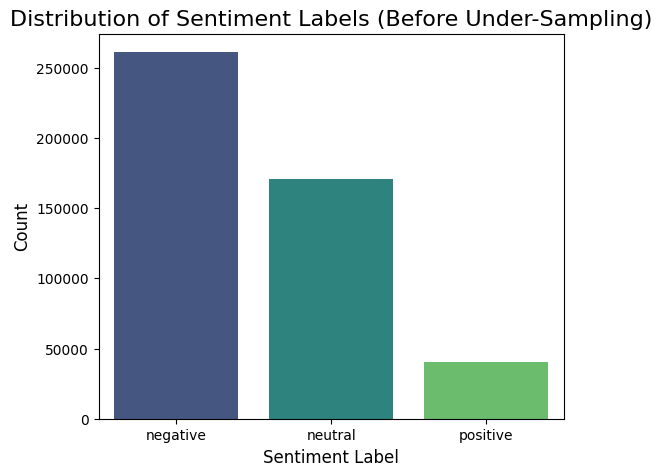

In [ ]:
plt.figure(figsize=(6, 5))
sns.countplot(data=data, x='sentiment_label', palette='viridis')
plt.title("Distribution of Sentiment Labels (Before Under-Sampling)", fontsize=16)
plt.xlabel("Sentiment Label", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=label_encoder.classes_, fontsize=10)
plt.show()

# Under-sampling

In [ ]:
# Apply under-sampling
from imblearn.under_sampling import RandomUnderSampler
import random

rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(data['content'].values.reshape(-1, 1), data['sentiment_label'])
resampled_data = pd.DataFrame({'content': X_res.flatten(), 'sentiment_label': y_res})

In [ ]:
# Display the class distribution after under-sampling
print("Class distribution after balanced_data-sampling:")
print(resampled_data['sentiment_label'].value_counts())

Class distribution after balanced_data-sampling:
sentiment_label
0    40553
1    40553
2    40553
Name: count, dtype: int64


In [ ]:
resampled_data.head(5)

,content,sentiment_label
0,𝗣𝗿𝗮𝘆 𝗳𝗼𝗿 𝗧𝘂𝗿𝗸𝗲𝘆 𝗮𝗻𝗱 𝗦𝘆𝗿𝗶𝗮 🙏🏼 A powerful 7.8 m...,0
1,AN İTİBARİ İLE ANKARA - NİĞDE OTOBANI AÇIK YOL...,0
2,#Türkiye earthquake death toll rises More tha...,0
3,A magnitude-7.8 #earthquake has devastated par...,0
4,#sanliurfa 'da deprem sonrası ağır hasar alan ...,0


In [ ]:
resampled_data.to_csv('resampled_data.csv', index=False)

<ipython-input-58-1cb477c20b1b>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=resampled_data, x='sentiment_label', palette='viridis')


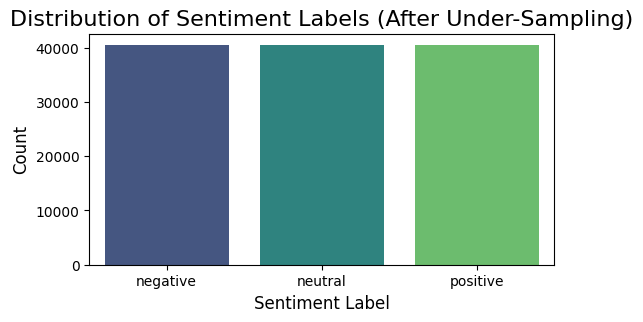

In [ ]:
plt.figure(figsize=(6, 3))
sns.countplot(data=resampled_data, x='sentiment_label', palette='viridis')
plt.title("Distribution of Sentiment Labels (After Under-Sampling)", fontsize=16)
plt.xlabel("Sentiment Label", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=label_encoder.classes_, fontsize=10)
plt.show()

# Oversampling and under-sampling

In [ ]:
# Determine the size of the median class
median_class_size = len(class_1)

# Under-sample class 0
class_0_under = resample(class_0,
                         replace=False, # No replacement
                         n_samples=median_class_size, # Match class 1 size
                         random_state=42)

# Over-sample class 2
class_2_over = resample(class_2,
                        replace=True, # Allow replacement
                        n_samples=median_class_size, # Match class 1 size
                        random_state=42)

# Combine the balanced classes
balanced_data = pd.concat([class_0_under, class_1, class_2_over])

# Shuffle the dataset
balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
# Check the size of the new dataset
print("Balanced class counts:")
print(balanced_data['sentiment_label'].value_counts())

Balanced class counts:
sentiment_label
1    171021
0    171021
2    171021
Name: count, dtype: int64


In [ ]:
balanced_data.to_csv('balanced_data.csv', index=False)

<ipython-input-225-930f9c241864>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=balanced_data, x='sentiment_label', palette='viridis')


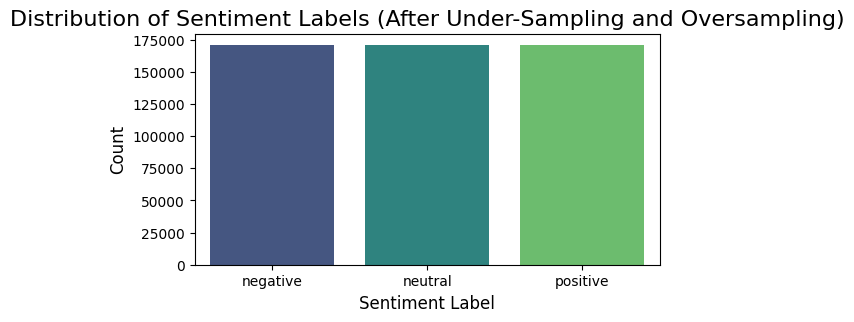

In [ ]:
plt.figure(figsize=(6, 3))
sns.countplot(data=balanced_data, x='sentiment_label', palette='viridis')
plt.title("Distribution of Sentiment Labels (After Under-Sampling and Oversampling)", fontsize=16)
plt.xlabel("Sentiment Label", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=label_encoder.classes_, fontsize=10)
plt.show()

# Oversampling

In [ ]:
# Determine the size of the majority class (class 0)
majority_class_size = len(class_0)

# Over-sample class 1 and class 2
class_1_over = resample(class_1,
                        replace=True,  # Allow replacement
                        n_samples=majority_class_size,  # Match class 0 size
                        random_state=42)

class_2_over = resample(class_2,
                        replace=True,  # Allow replacement
                        n_samples=majority_class_size,  # Match class 0 size
                        random_state=42)

# Combine the classes
balanced_data = pd.concat([class_0, class_1_over, class_2_over])

# Shuffle the dataset
balanced_data = balanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

In [ ]:
# Check the size of the new dataset
print("Balanced class counts:")
print(balanced_data['sentiment_label'].value_counts())

Balanced class counts:
sentiment_label
2    261097
0    261097
1    261097
Name: count, dtype: int64


<ipython-input-13-a89025364dfa>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=balanced_data, x='sentiment_label', palette='viridis')


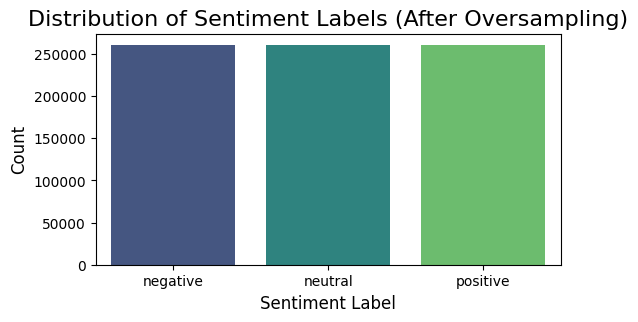

In [ ]:
plt.figure(figsize=(6, 3))
sns.countplot(data=balanced_data, x='sentiment_label', palette='viridis')
plt.title("Distribution of Sentiment Labels (After Oversampling)", fontsize=16)
plt.xlabel("Sentiment Label", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=label_encoder.classes_, fontsize=10)
plt.show()

In [ ]:
balanced_data.to_csv('balanced_data.csv', index=False)

# Spark section

In [ ]:
########################################## Prepare environment #####################################

#######  Automated script (Shell commands) ########

# The shell command to show the path to the Java executable in the system
!which java

# List Java Virtual Machine (JVM) installations on the system
!ls /usr/lib/jvm/

# Install the OpenJDK 8 JDK in headless mode without displaying much information during the installation process
!apt-get install openjdk-8-jdk-headless -qq > /dev/null

# Download the latest Apache Spark distribution archive file from the given URL
!wget -q https://dlcdn.apache.org/spark/spark-3.5.4/spark-3.5.4-bin-hadoop3.tgz

# Extract Spark Archive file
!tar xf spark-3.5.4-bin-hadoop3.tgz

# Install the findspark Python package which is often used to make it more convenient to use Spark in a Python setting
!pip install -q findspark

# Install the pyspark which is the Python API for Apache Spark, a powerful open-source distributed computing system
!pip install -q pyspark

# Check the download
!ls

/usr/bin/java
java-1.11.0-openjdk-amd64  java-1.8.0-openjdk-amd64
java-11-openjdk-amd64	   java-8-openjdk-amd64
tar: spark-3.5.4-bin-hadoop3.tgz: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now
drive  resampled_data.csv  sample_data


In [ ]:
#################### Setting environment variables #####################################

import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.4-bin-hadoop3"

In [ ]:
# Initializes the findspark module, which modifies the Python environment by adding the
# path to the Spark binaries to the 'PATH' variable, and sets other necessary environment variables

import findspark
findspark.init()
findspark.find()

Exception: Unable to find py4j in /content/spark-3.5.4-bin-hadoop3/python, your SPARK_HOME may not be configured correctly

In [ ]:
#################### Import necessary packages #####################################

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import random


from pyspark.sql import SparkSession
from pyspark.ml  import Pipeline as SparkPipeline
from pyspark.sql import SQLContext, SparkSession
from pyspark.sql.functions import *
from pyspark.ml.feature import StringIndexer, VectorAssembler, QuantileDiscretizer
from pyspark.ml.evaluation import MulticlassClassificationEvaluator


from operator import add
from google.colab import files

In [ ]:
# Create a Spark session in local mode on a single machine

#.master("local") \   Rawan

spark = SparkSession.builder \
    .appName("Multilingual") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.executor.extraJavaOptions", "-XX:+UseG1GC") \
    .getOrCreate()

sc = spark.sparkContext

# Check Spark Session Information
spark


In [ ]:
# Read a CSV file where the first row is a header, columns are separated by commas, and text fields are enclosed in double quotes
# The escape option is set to handle cases where double quotes are part of the text

df_spark = spark.read.option("header", "true").option("delimiter", ",").option("quote", "\"").option("escape", "\"").csv("balanced_data.csv")
#df2 = spark.read.option("header", "true").option("delimiter", ",").option("quote", "\"").option("escape", "\"").csv("monkeypox.csv")

#common_columns = set(df1.columns).intersection(set(df2.columns))

# Select only common columns for both DataFrames
#df1_common = df1.select(*common_columns)
#df2_common = df2.select(*common_columns)

# Append rows from df1 to df2
#df_spark = df2_common.union(df1_common)

#print("Number of rows in the dataset 1 =", df1.count())
#print("Number of rows in the dataset 2 =", df2.count())
print("Number of rows in the merged dataset =", df_spark.count())

In [ ]:
print("Number of rows in the merged dataset =", df_spark.count())

In [ ]:
#The schema of the DataFrame
df_spark.printSchema()

In [ ]:
######################################### Original Tweet #######################################
df_spark.select("content").show(5, truncate=False)

# Data Preprocessing

In [ ]:
#df_spark = df_spark.withColumn('text', lower(df_spark['text']))  # Convert Text to Lowercase
df_spark = df_spark.withColumn('content', regexp_replace(df_spark['content'], '[^\w\s]', '')) # Removes non-alphanumeric characters (excluding whitespace)
df_spark = df_spark.withColumn('content', regexp_replace(df_spark['content'] ,'http\S+', ''))  # Remove URLs
df_spark = df_spark.withColumn('content', regexp_replace(df_spark['content'] ,'@[A-Za-z0-9]+', '')) # Remove mentions
df_spark = df_spark.withColumn('content', regexp_replace(df_spark['content'] ,'[^a-zA-Z0-9\s]', ''))  # Remove special characters
df_spark = df_spark.withColumn('content', regexp_replace(df_spark['content'] ,"["
                           u"\U0001F600-\U0001F64F"  # emoticons
                           u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                           u"\U0001F680-\U0001F6FF"  # transport & map symbols
                           u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                           u"\U00002702-\U000027B0"  # includes symbols from ✂ to ➰
                           u"\U000024C2-\U0001F251" "]",'')) # includes symbols Ⓜ to 🉑

NameError: name 'df_spark' is not defined

In [ ]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from pyspark.ml.feature import Tokenizer, StopWordsRemover

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

# Tokenize
tokenizer = Tokenizer(inputCol="content", outputCol="tokens")
df_spark  = tokenizer.transform(df_spark)

# Remove stopwords
remover = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")
df_spark  = remover.transform(df_spark)

# Join tokens back into a text column
df_spark = df_spark.withColumn("cleaned_tweet",concat_ws(" ", df_spark["filtered_tokens"]))
df_spark= df_spark.drop("tokens").drop("filtered_tokens").drop("content").withColumnRenamed("cleaned_tweet", "content")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
# 3. Define stopwords for English, Turkish, Arabic languages
from pyspark.ml.feature import Tokenizer, StopWordsRemover

english_stopwords = StopWordsRemover.loadDefaultStopWords("english")
turkish_stopwords = StopWordsRemover.loadDefaultStopWords("turkish")

# Define custom Arabic stopwords (you can expand this list as needed)
arabic_stopwords = [
    "ال", "في", "على", "من", "إلى", "عن", "مع", "التي", "هذا", "هذه", "ذلك", "ذلكم", "هؤلاء",
    "وأ", "أو", "لكن", "ثم", "يكون", "قد", "كان", "فيه", "أن", "إن", "إذن", "إذا", "أين", "كيف", "منذ"
]

# Combine all stopwords into one list
#all_stopwords = english_stopwords + turkish_stopwords + arabic_stopwords

In [ ]:
from pyspark.sql.functions import concat_ws

# Tokenize the content
tokenizer = Tokenizer(inputCol="content", outputCol="tokens")
df_spark = tokenizer.transform(df_spark)

# Remove stopwords
remover = StopWordsRemover(inputCol="tokens", outputCol="filtered_tokens")
remover.setStopWords(english_stopwords + turkish_stopwords + arabic_stopwords)  # Set combined stopwords
df_spark = remover.transform(df_spark)

# Join tokens back into a text column
df_spark = df_spark.withColumn("cleaned_tweet", concat_ws(" ", df_spark["filtered_tokens"]))

# Drop unnecessary columns and rename the cleaned column
df_spark = df_spark.drop("tokens", "filtered_tokens", "content").withColumnRenamed("cleaned_tweet", "content")

# Show the processed DataFrame
df_spark.show(5)

+--------+---------------+---------------+--------------------+
|language|sentiment_label|sentiment_score|             content|
+--------+---------------+---------------+--------------------+
|      en|              2|         0.5284|little 4 years ol...|
|      en|              0|           0.93|aktalkies mybmc p...|
|      en|              0|         0.7009|turkish president...|
|      tr|              1|         0.4073|lgl llerde k kard...|
|      en|              2|         0.4035|heart goes turkey...|
+--------+---------------+---------------+--------------------+
only showing top 5 rows



In [ ]:
######################################### Cleaned Tweet #######################################

df_spark.select("content").show(5, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|content                                                                                                                                                                                     |
+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|little 4 years old angel named sude rescued hatay 104 hours rubble miracle  turkey turkiye turkeyearthquake earthquaketurkey earthquake earthquakeinturkey                                  |
|aktalkies mybmc pray god  nothing ever like turkey today happens mumbai prepared  rather sitting ducks disaster                                                                             |
|turkish president tayyip erdoan decrees 7day

In [ ]:
# Step 7: Display the cleaned DataFrame
df_spark.show(5, truncate=False)

+--------+---------------+---------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|language|sentiment_label|sentiment_score|content                                                                                                                                                                                     |
+--------+---------------+---------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|en      |2              |0.5284         |little 4 years old angel named sude rescued hatay 104 hours rubble miracle  turkey turkiye turkeyearthquake earthquaketurkey earthquake earthquakeinturkey                                  |
|en      |0              |0.93           |aktalkies mybmc pray god  noth

# sentiment_label

In [ ]:
df_spark.groupBy("sentiment_label").count().show()

+--------------------+------+
|     sentiment_label| count|
+--------------------+------+
|                  en|     2|
| killing 254 peop...|     1|
|                   0|261096|
|                NULL|   152|
|                000)|     1|
|                  ar|     4|
|                   1|261085|
|    Caserta province|     1|
|                   2|261097|
+--------------------+------+



In [ ]:
print("Number of rows in the cleaned dataset =", df_spark.count())

Number of rows in the cleaned dataset = 783439


In [ ]:
from pyspark.sql.functions import col

# Filter out rows where 'sentiment_label' is not one of the valid numeric labels (0, 1, 2)
df_cleaned = df_spark.filter(col("sentiment_label").isin(["0", "1", "2"]))

# Check the number of rows in the cleaned dataset
print("Number of rows in the cleaned dataset =", df_cleaned.count())

# Verify the cleaned dataset
df_cleaned.groupBy("sentiment_label").count().show()

Number of rows in the cleaned dataset = 783278
+---------------+------+
|sentiment_label| count|
+---------------+------+
|              0|261096|
|              1|261085|
|              2|261097|
+---------------+------+



In [ ]:
df_cleaned.show(truncate=False)

+--------+---------------+---------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|language|sentiment_label|sentiment_score|content                                                                                                                                                                                                        |
+--------+---------------+---------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|en      |2              |0.5284         |little 4 years old angel named sude rescued hatay 104 hours rubble miracle  turkey turkiye turkeyearthquake earthquaketurkey earthquake earthquakeinturkey                                                   

In [ ]:
#df_spark=df_spark.drop("_c0")
df_cleaned = df_cleaned.withColumnRenamed("sentiment_label","target")
df_cleaned.show(5)

+--------+------+---------------+--------------------+
|language|target|sentiment_score|             content|
+--------+------+---------------+--------------------+
|      en|     2|         0.5284|little 4 years ol...|
|      en|     0|           0.93|aktalkies mybmc p...|
|      en|     0|         0.7009|turkish president...|
|      tr|     1|         0.4073|lgl llerde k kard...|
|      en|     2|         0.4035|heart goes turkey...|
+--------+------+---------------+--------------------+
only showing top 5 rows



In [ ]:
df_cleaned=df_cleaned.dropna()
df_cleaned.groupBy("target").count().show()

+------+------+
|target| count|
+------+------+
|     0|261096|
|     1|261085|
|     2|261097|
+------+------+



In [ ]:
from pyspark.ml.feature import HashingTF, IDF, Tokenizer
from pyspark.ml.feature import IndexToString, StringIndexer
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.sql import Row
import logging
from pyspark.mllib.recommendation import ALS
import re

In [ ]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


In [ ]:
import nltk
from pyspark.sql import SparkSession
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, StringType
from nltk.tokenize import word_tokenize

nltk.download('punkt')

# Create a Spark session
'''spark = SparkSession.builder.appName("TokenizationExample").getOrCreate()



# Assuming 'text' is the column in your dataset that you want to tokenize
# Replace 'text' with the actual column name if different
column_to_tokenize = 'text'

# Define a UDF to tokenize the text


@udf(ArrayType(StringType()))
def tokenize_text2(text):
    if isinstance(text, str):
        try:
            return word_tokenize(text)
        except (TypeError, ValueError):
            return []
    else:
        return []

# Apply the UDF to the specified column
df_spark = df_spark.withColumn(column_to_tokenize, tokenize_text2(df_spark[column_to_tokenize]))

# Show the result
#df_spark.show(truncate=False)'''


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


'spark = SparkSession.builder.appName("TokenizationExample").getOrCreate()\n\n\n\n# Assuming \'text\' is the column in your dataset that you want to tokenize\n# Replace \'text\' with the actual column name if different\ncolumn_to_tokenize = \'text\'\n\n# Define a UDF to tokenize the text\n\n\n@udf(ArrayType(StringType()))\ndef tokenize_text2(text):\n    if isinstance(text, str):\n        try:\n            return word_tokenize(text)\n        except (TypeError, ValueError):\n            return []\n    else:\n        return []\n\n# Apply the UDF to the specified column\ndf_spark = df_spark.withColumn(column_to_tokenize, tokenize_text2(df_spark[column_to_tokenize]))\n\n# Show the result\n#df_spark.show(truncate=False)'

In [ ]:
from pyspark.ml.feature import HashingTF, IDF, Tokenizer
from pyspark.ml.feature import IndexToString, StringIndexer
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression
from pyspark.sql import Row
import logging
from pyspark.mllib.recommendation import ALS
import re

In [ ]:
def clean_tweet_ar(tweet=None):
    tweet = ' '.join(re.sub("(@[A-Za-z0–9]+)|([0-9A-Za-z \t])|(\w+:\/\/\S+)", " ", tweet).split())
    punctuations = '''!()-![]{};:+'"\,<>./?@#$%^&*_~…،'''
    tweet = ''.join([i for i in tweet if not i in punctuations])
    tweet = remove_emoji(tweet)
    tweet = [(tweet, "")]
    return tweet

In [ ]:
sentiment_RDD=df_cleaned.rdd

In [ ]:
data= sentiment_RDD.map(lambda line: line[0:]).map(lambda tweet: Row(tweet=tweet[3], target=tweet[1])).toDF()
data.show(5)

+--------------------+------+
|               tweet|target|
+--------------------+------+
|little 4 years ol...|     2|
|aktalkies mybmc p...|     0|
|turkish president...|     0|
|lgl llerde k kard...|     1|
|heart goes turkey...|     2|
+--------------------+------+
only showing top 5 rows



In [ ]:
tokenizer = Tokenizer(inputCol="tweet", outputCol="words")
hashtf = HashingTF(numFeatures=2 ** 16, inputCol="words", outputCol='tf')  # Set numFeatures to 5000
idf = IDF(inputCol='tf', outputCol="features", minDocFreq=5)  # minDocFreq: remove sparse terms
label_stringIdx = StringIndexer(inputCol="target", outputCol="label")

# Define the pipeline
pipeline = Pipeline(stages=[tokenizer, hashtf, idf, label_stringIdx])

#data= sentiment_RDD.map(lambda line: line[0].split(" ")).map(lambda words: Row(label=words[0], words=words[1:])).toDF()
pipelineFit = pipeline.fit(data)
data = pipelineFit.transform(data)

# Split the data into 70% training, 10% validation, and 20% testing
(train_set, validation_set, test_set) = data.randomSplit([0.7, 0.1, 0.2], seed=42)

# Print the sizes of each dataset
print(f"Training set size: {train_set.count()}")
print(f"Validation set size: {validation_set.count()}")
print(f"Testing set size: {test_set.count()}")

Training set size: 548303
Validation set size: 78195
Testing set size: 156780


In [ ]:
def predict_sentiment( schema):
        """Gets predictions for a given tweet formatted RDD
        Returns: an RDD with format {"sentiment":"POSITIVE"}
        """
        test = pipelineFit.transform(schema)
        predict = model.transform(test)
        converter = IndexToString(inputCol="prediction", outputCol="predicted_label", labels=pipelineFit.stages[3].labels)
        converted = converter.transform(predict)
        return converted.select("predicted_label").collect()[0].asDict()

In [ ]:
def get_sentiment( tweet):
  rdd = sc.parallelize(clean_tweet_ar(tweet))
  tweet_rdd = rdd.map(lambda x: Row(tweet=x[0], target=x[1]))
  schema = sc.createDataFrame(tweet_rdd)
  x=predict_sentiment(schema)

In [ ]:
from time import *
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import BinaryClassificationMetrics, MulticlassMetrics
from pyspark.mllib.evaluation import MulticlassMetrics

In [ ]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

def print_performance_metrics(predictions):
    # Evaluate model accuracy
    evaluator = MulticlassClassificationEvaluator(predictionCol="prediction", labelCol="label", metricName="accuracy")
    accuracy = evaluator.evaluate(predictions)
    print(f"Accuracy = {accuracy:.4f}")

    # Evaluate F1-score
    f1 = evaluator.evaluate(predictions, {evaluator.metricName: "f1"})
    print(f"F1 = {f1:.4f}")

    # Get RDD of predictions and labels for mllib evaluation metrics
    predictionAndLabels = predictions.select("prediction", "label").rdd.map(lambda row: (row[0], row[1]))

    # Instantiate metrics object
    multi_metrics = MulticlassMetrics(predictionAndLabels)

    # Calculate precision and recall for each class
    labels = sorted(predictions.select("label").distinct().rdd.map(lambda r: r[0]).collect())
    total_precision = 0
    total_recall = 0

    print("\nClass-wise Precision and Recall:")
    for label in labels:
        precision = multi_metrics.precision(label)
        recall = multi_metrics.recall(label)
        total_precision += precision
        total_recall += recall
        print(f"Class {label}: Precision = {precision:.4f}, Recall = {recall:.4f}")

    # Calculate average precision and recall
    average_precision = total_precision / len(labels)
    average_recall = total_recall / len(labels)

    print(f"\nAverage Precision = {average_precision:.4f}")
    print(f"Average Recall = {average_recall:.4f}")

## **worked untill here**
worked untill here
**bold text**worked untill [here](https://)
**worked untill here**

# LR

In [ ]:
lr = LogisticRegression()
lrModel = lr.fit(train_set)

In [ ]:
lrpredictions_val = lrModel.transform(validation_set)
print_performance_metrics(lrpredictions_val)

Accuracy = 0.7485
F1 = 0.7447


/content/spark-3.5.4-bin-hadoop3/python/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



Class-wise Precision and Recall:
Class 0.0: Precision = 0.8024, Recall = 0.9146
Class 1.0: Precision = 0.7326, Recall = 0.6522
Class 2.0: Precision = 0.7004, Recall = 0.6796

Average Precision = 0.7451
Average Recall = 0.7488


In [ ]:
lrpredictions_test = lrModel.transform(test_set)
print_performance_metrics(lrpredictions_test)

Accuracy = 0.7541
F1 = 0.7506

Class-wise Precision and Recall:
Class 0.0: Precision = 0.8048, Recall = 0.9133
Class 1.0: Precision = 0.7418, Recall = 0.6641
Class 2.0: Precision = 0.7067, Recall = 0.6863

Average Precision = 0.7511
Average Recall = 0.7546


# RF

In [ ]:
from pyspark.ml.classification import RandomForestClassifier

# Use 'featureSubsetStrategy' instead of 'maxFeatures'
# Remove 'min_samples_split' as it's not a valid parameter in PySpark's RandomForestClassifier
rf_classifier = RandomForestClassifier(numTrees=100, maxDepth=7, featureSubsetStrategy='sqrt', minInstancesPerNode=2)
rfModel = rf_classifier.fit(train_set)
rfpredictions = rfModel.transform(test_set)

In [ ]:
print_performance_metrics(rfpredictions)

Accuracy = 0.5830
F1 = 0.5789

Class-wise Precision and Recall:
Class 0.0: Precision = 0.6009, Recall = 0.6749
Class 1.0: Precision = 0.6527, Recall = 0.4375
Class 2.0: Precision = 0.5276, Recall = 0.6363

Average Precision = 0.5937
Average Recall = 0.5829


In [ ]:
rfpredictions_val = rfModel.transform(validation_set)
print_performance_metrics(rfpredictions_val)

Accuracy = 0.5836
F1 = 0.5795


/content/spark-3.5.4-bin-hadoop3/python/pyspark/sql/context.py:158: FutureWarning: Deprecated in 3.0.0. Use SparkSession.builder.getOrCreate() instead.
  warnings.warn(



Class-wise Precision and Recall:
Class 0.0: Precision = 0.6057, Recall = 0.6751
Class 1.0: Precision = 0.6464, Recall = 0.4379
Class 2.0: Precision = 0.5277, Recall = 0.6382

Average Precision = 0.5933
Average Recall = 0.5837


# NB

In [ ]:
from pyspark.ml.classification import NaiveBayes
nb = NaiveBayes(smoothing=1)
nbModel = nb.fit(train_set)

In [ ]:
nbpredictions_val = nbModel.transform(validation_set)
print_performance_metrics(nbpredictions_val)

Accuracy = 0.7020
F1 = 0.6973

Class-wise Precision and Recall:
Class 0.0: Precision = 0.6873, Recall = 0.8684
Class 1.0: Precision = 0.7086, Recall = 0.6452
Class 2.0: Precision = 0.7171, Recall = 0.5939

Average Precision = 0.7043
Average Recall = 0.7025


In [ ]:
nbpredictions_test = nbModel.transform(test_set)
print_performance_metrics(nbpredictions_test)

Accuracy = 0.7039
F1 = 0.6990

Class-wise Precision and Recall:
Class 0.0: Precision = 0.6904, Recall = 0.8728
Class 1.0: Precision = 0.7081, Recall = 0.6490
Class 2.0: Precision = 0.7197, Recall = 0.5914

Average Precision = 0.7061
Average Recall = 0.7044


# DT

In [ ]:
from pyspark.ml.classification import DecisionTreeClassifier

# Remove 'maxLeaves' and use 'maxBins' instead to control tree size
dt = DecisionTreeClassifier()
# maxBins affects the number of bins used for continuous feature discretization, indirectly influencing tree size.

dtModel = dt.fit(train_set)
dtpredictions = dtModel.transform(test_set)

In [ ]:
print_performance_metrics(dtpredictions)

Accuracy = 0.4603
F1 = 0.4403

Class-wise Precision and Recall:
Class 0.0: Precision = 0.5223, Recall = 0.4822
Class 1.0: Precision = 0.4170, Recall = 0.6801
Class 2.0: Precision = 0.4916, Recall = 0.2190

Average Precision = 0.4770
Average Recall = 0.4605


In [ ]:
dtpredictions_val = dtModel.transform(validation_set)
print_performance_metrics(dtpredictions_val)

Accuracy = 0.4561
F1 = 0.4353

Class-wise Precision and Recall:
Class 0.0: Precision = 0.5228, Recall = 0.4758
Class 1.0: Precision = 0.4127, Recall = 0.6826
Class 2.0: Precision = 0.4815, Recall = 0.2122

Average Precision = 0.4723
Average Recall = 0.4569
